# 03 Change: what happened to Keys lawns across the irrigation shutoff

The question: when Tahoe Keys irrigation was shut off (2021 and 2022 seasons), did people
convert to low-water landscaping, let the lawn die and leave it, or let it die and start
watering again?

Two complementary views:

**Pixel view (where the lawn was).** The lawn footprint is fixed from the last pre-shutoff
image (2020, backed by 2018). Every later year is then asked one question per footprint pixel:
is it still green? This is the cleanest way to tell lawn from mature trees without arguing
about spectral thresholds: irrigated turf browned out in the July 2022 image, canopy did not.
With the lidar canopy mask in place the footprint is already tree-free; without it, the
2020-to-2022 difference is what separates the two.

**Parcel view (trajectory classes).** Lawn area per parcel per year from notebook 02, rolled
into pre / during / post windows and classified: kept, died and recovered, died and stayed
converted, gained, never had lawn. Thresholds are in `config.yaml` under `change`.

The post window needs a post-shutoff image. Until 2024 NAIP (or a Nearmap capture) is added
in `config.yaml`, the post-dependent classes are reported as pending.

In [1]:
import sys
from pathlib import Path

print(sys.executable)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.io import load_config, get_logger
from src import grid as G

cfg = load_config()
log = get_logger("03_change")
RAW = ROOT / cfg["paths"]["raw"]
PROC = ROOT / cfg["paths"]["processed"]
OUT = ROOT / cfg["paths"]["outputs"]
C = cfg["change"]

2026-09-17 21:40:36 | INFO | 03_change | Log file: <repo>/logs/03_change_2026-09-17_214036.log


/usr/bin/python3


In [2]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

grid = G.load_grid(PROC / "grid.json")
PX_M2 = G.pixel_area_m2(grid)
long = pd.read_parquet(PROC / "lawn_by_parcel_all_years.parquet")
long["APN"] = long["APN"].astype(str)
years = sorted(long["year"].unique().tolist())
dates = long.groupby("year")["acq_date"].agg(lambda s: s.mode().iloc[0]).to_dict()

pre = [y for y in C["pre_years"] if y in years]
during = [y for y in C["during_years"] if y in years]
post = [y for y in C["post_years"] if y in years]
log.info(f"Image years {years}; windows pre={pre} during={during} post={post}")
if not during:
    raise RuntimeError("No image year inside the irrigation-off window. Check change.during_years.")
if not post:
    log.warning("No post-shutoff image yet. Recovery vs conversion classes will be reported as pending.")

parcel_id, _ = G.read_raster(PROC / "parcel_id.tif", grid)
n_parcels = int(parcel_id.max())
inp = parcel_id > 0
lidar_ok = rasterio.open(PROC / "ndsm.tif").tags().get("lidar_ok") == "True"
if not lidar_ok:
    log.warning("Lidar canopy mask absent: 'kept green' pixels will include tree canopy. Read the pixel view accordingly.")

2026-09-17 21:40:36 | INFO | 03_change | Image years [2016, 2018, 2020, 2022]; windows pre=[2016, 2018, 2020] during=[2022] post=[]


2026-09-17 21:40:36 | WARNING | 03_change | No post-shutoff image yet. Recovery vs conversion classes will be reported as pending.


2026-09-17 21:40:37 | WARNING | 03_change | Lidar canopy mask absent: 'kept green' pixels will include tree canopy. Read the pixel view accordingly.


## Pixel view: the lawn footprint and what happened on it

Footprint = lawn in the last pre-shutoff year, and also lawn in at least one earlier pre-year
(so a single-year fluke doesn't define it). Then per later year, footprint pixels are either
still green or not.

In [3]:
def lawn_of(year):
    cls, _ = G.read_raster(PROC / f"lawn_{year}.tif", grid)
    return cls == 1

last_pre = max(pre)
earlier = [y for y in pre if y != last_pre]
footprint = lawn_of(last_pre)
if earlier:
    footprint &= np.any([lawn_of(y) for y in earlier], axis=0)
log.info(f"Lawn footprint ({last_pre} backed by {earlier}): {footprint.sum() * PX_M2 / 4046.856:,.1f} acres")

during_green = np.all([lawn_of(y) for y in during], axis=0)   # green in every during-year image
died = footprint & ~during_green
kept = footprint & during_green

# Trajectory raster: 1 kept green through shutoff, 2 died during shutoff,
# 3 died then recovered, 4 died and stayed non-lawn, 5 new lawn after shutoff (post years only)
traj = np.zeros(footprint.shape, dtype="uint8")
traj[kept] = 1
traj[died] = 2
if post:
    post_green = np.any([lawn_of(y) for y in post], axis=0)
    traj[died & post_green] = 3
    traj[died & ~post_green] = 4
    traj[inp & post_green & ~footprint] = 5
G.write_raster(PROC / "lawn_trajectory.tif", traj, grid, nodata=0, tags={
    "classes": "1 kept green through shutoff,2 died during shutoff (no post image),3 died then recovered,4 died and stayed,5 new lawn post",
    "footprint_years": f"{last_pre} & any of {earlier}", "during": str(during), "post": str(post), "lidar_ok": str(lidar_ok)})

acres = lambda m: m.sum() * PX_M2 / 4046.856
log.info(f"Footprint kept green in {during}: {acres(kept):,.1f} ac ({kept.sum() / max(footprint.sum(), 1) * 100:.0f}%); "
         f"died: {acres(died):,.1f} ac ({died.sum() / max(footprint.sum(), 1) * 100:.0f}%)")
if post:
    log.info(f"Of the die-off: recovered by {post} {acres(traj == 3):,.1f} ac, stayed non-lawn {acres(traj == 4):,.1f} ac; "
             f"new lawn outside the footprint {acres(traj == 5):,.1f} ac")

2026-09-17 21:40:37 | INFO | 03_change | Lawn footprint (2020 backed by [2016, 2018]): 87.3 acres


2026-09-17 21:40:37 | INFO | 03_change | Footprint kept green in [2022]: 51.2 ac (59%); died: 36.1 ac (41%)


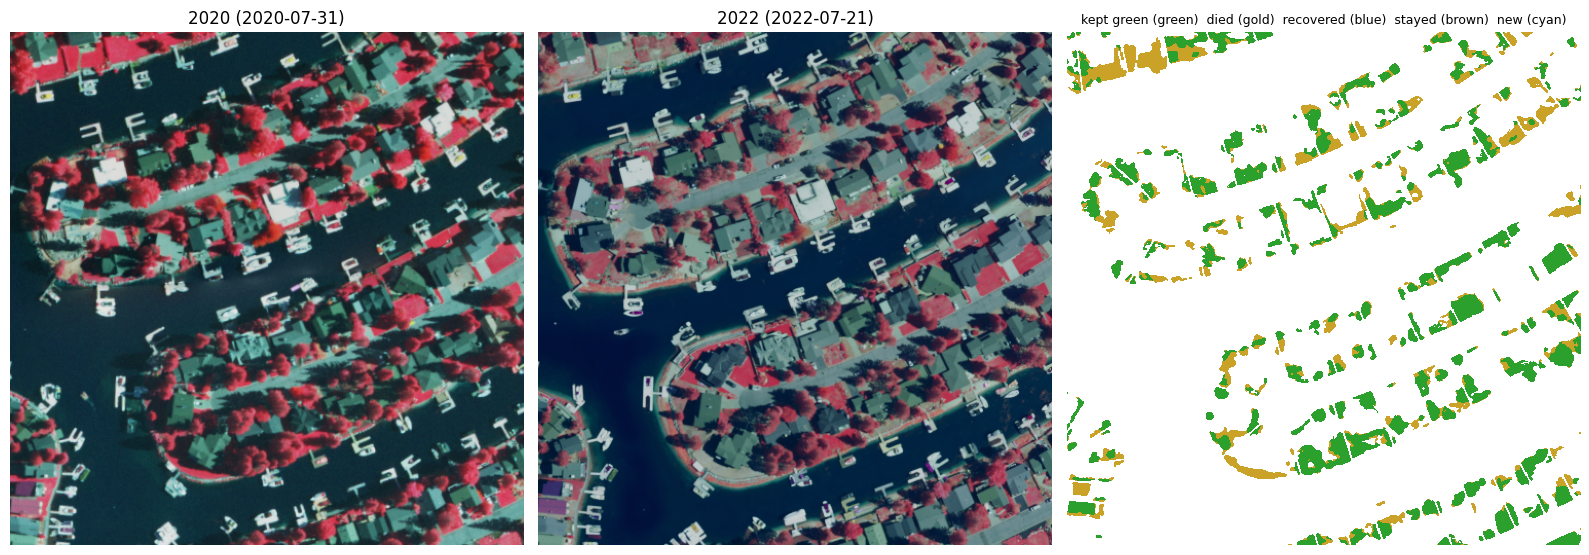

In [4]:
# The story in one figure: the last pre-shutoff image, the during image, and the trajectory map, on one block
ys, xs = np.where(inp)
cy, cx = int(np.median(ys)), int(np.median(xs))
win = (slice(cy - 250, cy + 250), slice(cx - 250, cx + 250))

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, year in zip(axes[:2], [last_pre, during[0]]):
    arr, _ = G.read_raster(RAW / "naip" / f"naip_{year}.tif", grid)
    ax.imshow(np.stack([arr[3], arr[0], arr[1]], axis=-1)[win].astype(float) / 255)
    ax.set_title(f"{year} ({dates[year]})"); ax.axis("off")
cmap = ListedColormap(["white", "#2ca02c", "#c9a227", "#1f77b4", "#8c564b", "#17becf"])
axes[2].imshow(traj[win], cmap=cmap, vmin=0, vmax=5, interpolation="nearest")
axes[2].set_title("kept green (green)  died (gold)  recovered (blue)  stayed (brown)  new (cyan)", fontsize=9); axes[2].axis("off")
plt.tight_layout()

## Parcel view: roll the pixel trajectory up by parcel

Two per-parcel tables are built here. The first is straight from the trajectory raster
(footprint area, kept, died, recovered, stayed, new). The second is the window summary from
the yearly lawn areas in notebook 02. They agree in aggregate; the first is more readable for
"what happened to the lawn that was there", the second is what feeds the class rules.

In [5]:
def tab(mask):
    return np.bincount(parcel_id[mask], minlength=n_parcels + 1)[1:] * PX_M2

fp = pd.DataFrame({
    "pid": np.arange(1, n_parcels + 1),
    "footprint_m2": tab(footprint),
    "kept_m2": tab(traj == 1),
    "died_m2": tab(died),
    "recovered_m2": tab(traj == 3) if post else np.nan,
    "stayed_m2": tab(traj == 4) if post else np.nan,
    "new_m2": tab(traj == 5) if post else np.nan,
})
fp["died_pct"] = np.where(fp["footprint_m2"] > 0, fp["died_m2"] / fp["footprint_m2"] * 100, np.nan)
if post:
    fp["recovered_pct_of_died"] = np.where(fp["died_m2"] > 0, fp["recovered_m2"] / fp["died_m2"] * 100, np.nan)

wide = long.pivot(index="APN", columns="year", values="lawn_m2")
wide.columns = [f"lawn_m2_{y}" for y in wide.columns]
meta = long[long["year"] == years[-1]].set_index("APN")[["pid", "APO_ADDRESS", "EXISTING_LANDUSE", "ZONING_DESCRIPTION", "CATCHMENT",
                                                          "YEAR_BUILT", "parcel_m2", "eligible_m2", "canopy_m2"]]
P = meta.join(wide).reset_index().merge(fp, on="pid", how="left")
P["pre_m2"] = P[[f"lawn_m2_{y}" for y in pre]].mean(axis=1)
P["pre_last_m2"] = P[f"lawn_m2_{last_pre}"]
P["during_m2"] = P[[f"lawn_m2_{y}" for y in during]].mean(axis=1)
P["post_m2"] = P[[f"lawn_m2_{y}" for y in post]].mean(axis=1) if post else np.nan
P["change_during_m2"] = P["during_m2"] - P["pre_last_m2"]
P["change_during_pct"] = np.where(P["pre_last_m2"] > 0, P["change_during_m2"] / P["pre_last_m2"] * 100, np.nan)

In [6]:
def classify(row):
    had = row["pre_last_m2"] >= C["lawn_present_min_m2"]
    drop = row["pre_last_m2"] - row["during_m2"]
    big_drop = had and drop >= C["abs_change_min_m2"] and drop / row["pre_last_m2"] >= C["rel_change_min"]
    if not had:
        if post and row["post_m2"] >= C["lawn_present_min_m2"] and (row["post_m2"] - row["pre_last_m2"]) >= C["abs_change_min_m2"]:
            return "gained lawn after shutoff"
        return "no lawn before shutoff"
    if not big_drop:
        return "kept lawn through shutoff"
    if not post:
        return "lost lawn during shutoff (post image pending)"
    if row["post_m2"] >= C["recovery_fraction"] * row["pre_last_m2"]:
        return "lost during shutoff, recovered after"
    return "lost during shutoff, stayed converted or bare"

P["trajectory"] = P.apply(classify, axis=1)
P["in_analysis"] = P["EXISTING_LANDUSE"].isin(cfg["analysis"]["landuse_include"])
order = ["kept lawn through shutoff", "lost during shutoff, recovered after", "lost during shutoff, stayed converted or bare",
         "lost lawn during shutoff (post image pending)", "gained lawn after shutoff", "no lawn before shutoff"]
counts = (P[P["in_analysis"]]["trajectory"].value_counts().reindex(order).dropna().astype(int))
log.info("Parcel trajectories (analysis land uses):\n" + counts.to_string())
counts.to_frame("parcels").to_csv(OUT / "trajectory_counts.csv")
counts

2026-09-17 21:40:38 | INFO | 03_change | Parcel trajectories (analysis land uses):
trajectory
kept lawn through shutoff                        622
lost lawn during shutoff (post image pending)    460
no lawn before shutoff                           342


trajectory
kept lawn through shutoff                        622
lost lawn during shutoff (post image pending)    460
no lawn before shutoff                           342
Name: count, dtype: int64

2026-09-17 21:40:38 | INFO | 03_change | Wrote 1,450 parcels to outputs/keys_lawn_change.gpkg and .csv


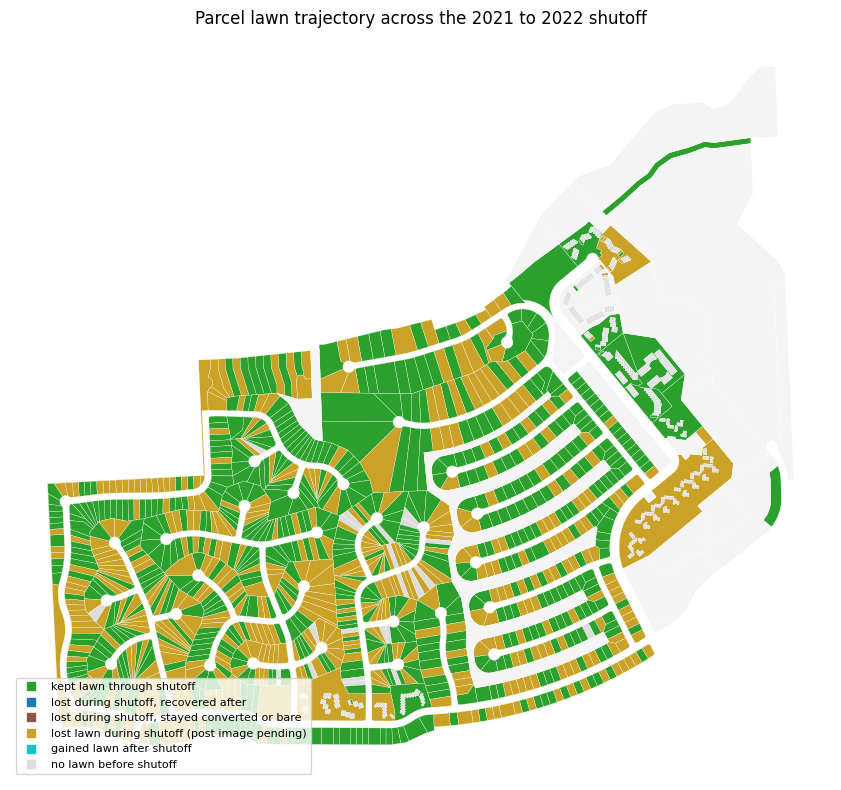

In [7]:
# Per-parcel output table and a GeoPackage for mapping in Pro
parcels = gpd.read_file(PROC / "keys_parcels.gpkg", layer="parcels")[["APN", "geometry"]]
parcels["APN"] = parcels["APN"].astype(str)
P_out = parcels.merge(P, on="APN", how="left")
P_out.to_file(OUT / "keys_lawn_change.gpkg", layer="parcels", driver="GPKG")
P.drop(columns=["pid"]).to_csv(OUT / "keys_lawn_change_by_parcel.csv", index=False)
log.info(f"Wrote {len(P):,} parcels to outputs/keys_lawn_change.gpkg and .csv")

fig, ax = plt.subplots(figsize=(9, 8))
cmap_t = {"kept lawn through shutoff": "#2ca02c", "lost during shutoff, recovered after": "#1f77b4",
          "lost during shutoff, stayed converted or bare": "#8c564b", "lost lawn during shutoff (post image pending)": "#c9a227",
          "gained lawn after shutoff": "#17becf", "no lawn before shutoff": "#dddddd"}
P_out[P_out["in_analysis"]].plot(color=P_out[P_out["in_analysis"]]["trajectory"].map(cmap_t), ax=ax, edgecolor="white", linewidth=0.2)
P_out[~P_out["in_analysis"]].plot(color="#f4f4f4", ax=ax, edgecolor="white", linewidth=0.2)
for k, v in cmap_t.items():
    ax.plot([], [], "s", color=v, label=k)
ax.legend(fontsize=8, loc="lower left"); ax.set_axis_off(); ax.set_title("Parcel lawn trajectory across the 2021 to 2022 shutoff")
plt.tight_layout()

## Summaries and figures

,year,acq_date,lawn_acres,parcels_with_lawn,median_lawn_sqft,window
0,2016,2016-07-12,67.344101,1078,1598.439150,pre
1,2018,2018-09-17,73.047640,1073,1660.439214,pre
2,2020,2020-07-31,69.930731,1082,1662.376716,pre
3,2022,2022-07-21,49.349688,1016,1059.813594,during


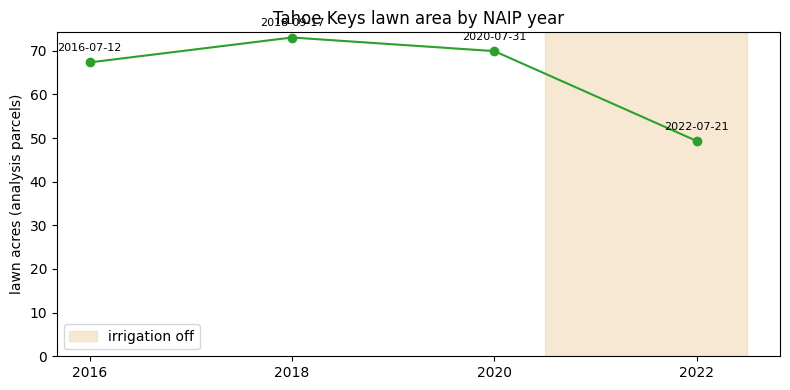

In [8]:
S = P[P["in_analysis"]]
totals = pd.DataFrame({
    "year": years,
    "acq_date": [dates[y] for y in years],
    "lawn_acres": [S[f"lawn_m2_{y}"].sum() / 4046.856 for y in years],
    "parcels_with_lawn": [(S[f"lawn_m2_{y}"] >= C["lawn_present_min_m2"]).sum() for y in years],
    "median_lawn_sqft": [S[f"lawn_m2_{y}"].median() * 10.7639 for y in years],
})
totals["window"] = ["pre" if y in pre else "during" if y in during else "post" if y in post else "" for y in years]
totals.to_csv(OUT / "lawn_totals_by_year.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axvspan(min(C["irrigation_off_years"]) - 0.5, max(C["irrigation_off_years"]) + 0.5, color="#f0d9b5", alpha=0.6, label="irrigation off")
ax.plot(totals["year"], totals["lawn_acres"], "o-", color="#2ca02c")
for _, r in totals.iterrows():
    ax.annotate(r["acq_date"], (r["year"], r["lawn_acres"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_ylabel("lawn acres (analysis parcels)"); ax.set_xticks(years); ax.set_ylim(0); ax.legend(loc="lower left")
ax.set_title("Tahoe Keys lawn area by NAIP year")
plt.tight_layout()
totals

trajectory,kept lawn through shutoff,lost lawn during shutoff (post image pending),no lawn before shutoff
ZONING_DESCRIPTION,,,
Tahoe Keys,605,441,81
Tahoe Keys Special Area #1,1,2,5
Tahoe Keys Special Area #2,16,17,256


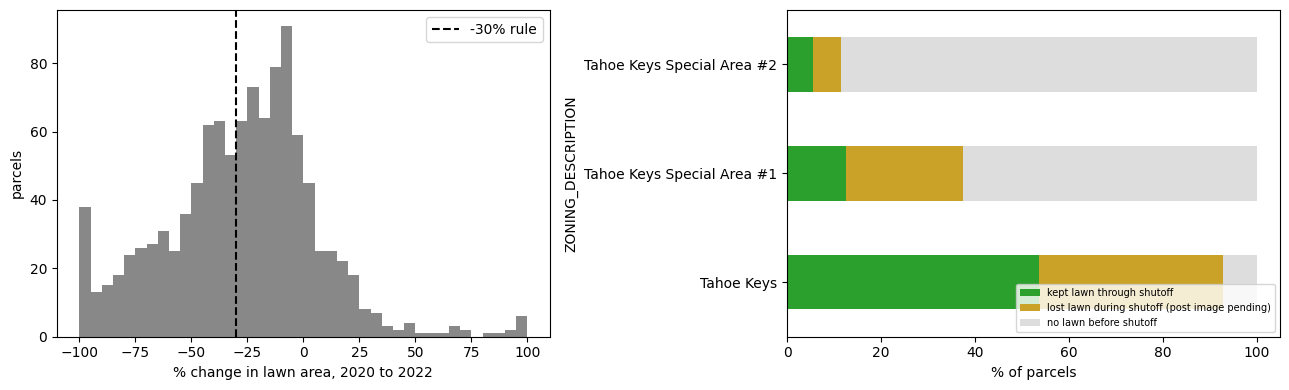

In [9]:
# Distribution of the during-shutoff change, and breakdowns by zoning area and land use
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
had = S[S["pre_last_m2"] >= C["lawn_present_min_m2"]]
axes[0].hist(had["change_during_pct"].clip(-100, 100), bins=40, color="#888")
axes[0].axvline(-C["rel_change_min"] * 100, color="k", ls="--", label=f"-{C['rel_change_min'] * 100:.0f}% rule")
axes[0].set_xlabel(f"% change in lawn area, {last_pre} to {during[0]}"); axes[0].set_ylabel("parcels"); axes[0].legend()
by_zone = pd.crosstab(S["ZONING_DESCRIPTION"], S["trajectory"], normalize="index").reindex(columns=[c for c in order if c in S["trajectory"].unique()]) * 100
by_zone.plot(kind="barh", stacked=True, ax=axes[1], color=[cmap_t[c] for c in by_zone.columns])
axes[1].set_xlabel("% of parcels"); axes[1].legend(fontsize=7, loc="lower right")
plt.tight_layout()
pd.crosstab(S["EXISTING_LANDUSE"], S["trajectory"]).to_csv(OUT / "trajectory_by_landuse.csv")
pd.crosstab(S["ZONING_DESCRIPTION"], S["trajectory"]).to_csv(OUT / "trajectory_by_zoning.csv")
pd.crosstab(S["ZONING_DESCRIPTION"], S["trajectory"])

## Validation sample

A stratified random sample of parcels by trajectory class, exported for manual digitizing in
Pro. For each sampled parcel, digitize the lawn on every image year into
`data/raw/validation/reference_lawn.gpkg` as layers `lawn_<year>` with an `APN` field. Only
lawn inside the parcel matters; canopy over lawn counts as lawn in the reference so the
comparison measures the whole method, including the canopy mask.

In [10]:
rng = np.random.default_rng(cfg["validation"]["random_seed"])
n = cfg["validation"]["n_per_stratum"]
parts = [g.sample(min(n, len(g)), random_state=int(rng.integers(1e9))) for _, g in S.groupby("trajectory")]
sample = (pd.concat(parts)[["APN", "APO_ADDRESS", "trajectory", "pre_last_m2", "during_m2", "post_m2"]]
          .sort_values(["trajectory", "APN"]))
sample["reviewer"] = ""
sample["notes"] = ""
sample.to_csv(OUT / "validation_sample.csv", index=False)
parcels.merge(sample, on="APN").to_file(OUT / "validation_sample.gpkg", layer="sample", driver="GPKG")
log.info(f"Validation sample: {len(sample)} parcels across {sample['trajectory'].nunique()} strata")
sample["trajectory"].value_counts()

2026-09-17 21:40:40 | INFO | 03_change | Validation sample: 36 parcels across 3 strata


trajectory
kept lawn through shutoff                        12
lost lawn during shutoff (post image pending)    12
no lawn before shutoff                           12
Name: count, dtype: int64

In [11]:
# Accuracy assessment, runs once the reference layer exists
ref_path = ROOT / cfg["validation"]["reference_gpkg"]
if not ref_path.exists():
    log.info(f"No reference layer at {ref_path}; skipping accuracy assessment")
else:
    import fiona
    from rasterio.features import rasterize
    layers = [l for l in fiona.listlayers(ref_path) if l.startswith("lawn_")]
    rows = []
    inset = cfg["analysis"]["parcel_inset_m"]
    for layer in layers:
        year = int(layer.split("_")[1])
        ref = gpd.read_file(ref_path, layer=layer).to_crs(epsg=grid["crs_epsg"])
        ref["APN"] = ref["APN"].astype(str)
        ref_r = rasterize([(g, 1) for g in ref.geometry], out_shape=(grid["height"], grid["width"]),
                          transform=G.grid_transform(grid), dtype="uint8").astype(bool)
        mapped = lawn_of(year)
        for apn in ref["APN"].unique():
            pid = int(meta.loc[apn, "pid"])
            m = parcel_id == pid
            rows.append({"APN": apn, "year": year,
                         "ref_m2": (ref_r & m).sum() * PX_M2, "map_m2": (mapped & m).sum() * PX_M2,
                         "agree_m2": (ref_r & mapped & m).sum() * PX_M2,
                         "omission_m2": (ref_r & ~mapped & m).sum() * PX_M2,
                         "commission_m2": (~ref_r & mapped & m).sum() * PX_M2})
    acc = pd.DataFrame(rows)
    acc.to_csv(OUT / "validation_parcel_areas.csv", index=False)
    summary = acc.groupby("year").apply(lambda g: pd.Series({
        "n_parcels": len(g),
        "bias_m2": (g["map_m2"] - g["ref_m2"]).mean(),
        "rmse_m2": np.sqrt(((g["map_m2"] - g["ref_m2"]) ** 2).mean()),
        "r2": np.corrcoef(g["map_m2"], g["ref_m2"])[0, 1] ** 2,
        "producers_acc": g["agree_m2"].sum() / max(g["ref_m2"].sum(), 1),   # 1 - omission
        "users_acc": g["agree_m2"].sum() / max(g["map_m2"].sum(), 1),       # 1 - commission
    }))
    summary.to_csv(OUT / "validation_summary.csv")
    log.info("Validation summary:\n" + summary.round(3).to_string())
    display(summary.round(3))

2026-09-17 21:40:40 | INFO | 03_change | No reference layer at <repo>/data/raw/validation/reference_lawn.gpkg; skipping accuracy assessment


## Caveats that travel with these numbers

- Each year is a single summer snapshot. 2018 was flown in mid September, the others in July.
  Irrigated turf is green on both dates, but unirrigated grass and meadow are greener in July,
  so July images can slightly over-count lawn on the margins relative to September.
- The 2022 image is the second shutoff season. Lawns that died in 2021 and were re-established
  by July 2022 would read as kept. The 2021 season is not observed at all in NAIP.
- Converted to rock or mulch versus dead turf left in place look the same in this analysis
  (both are not-lawn). The post-window "stayed" class contains both. Distinguishing them needs
  finer imagery or a field check; see METHODS.md on Nearmap.
- Artificial turf reads as not-lawn (dark in NIR). It lands in "stayed converted or bare".
- The canopy mask is one lidar date (2022) applied to all years; tree removals or new plantings
  after 2022 are not tracked.

In [12]:
log.info("03_change complete")

2026-09-17 21:40:40 | INFO | 03_change | 03_change complete
